In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np
import gsw
import xarray as xr

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.DOT.operations as sops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod
from pyproj import Transformer


In [3]:
sat_ds_new = io.readers.readDOT("/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")
sat_ds_old = io.readers.readDOT("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", engine = 'scipy')

new_data = sat_ds_new.sel(time=4049)
old_data = sat_ds_old.sel(date=201102)

In [4]:

print(old_data.sel(lat = 70, lon = -140.25))
sops.get_geo_closest(new_data, lat_var='lats', lon_var='lons', search_lat=71, search_lon=-140.25)
old_data


<xarray.Dataset> Size: 24B
Dimensions:  ()
Coordinates:
    lon      float32 4B -140.2
    lat      float32 4B 70.0
    date     int32 4B 201102
Data variables:
    DOT      float32 4B 0.4166
    U        float32 4B -0.02262
    V        float32 4B -0.02651


<xarray.Dataset> Size: 503kB
Dimensions:  (lat: 87, lon: 480)
Coordinates:
  * lat      (lat) float32 348B 60.0 60.25 60.5 60.75 ... 80.75 81.0 81.25 81.5
  * lon      (lon) float32 2kB -179.2 -178.5 -177.8 -177.0 ... 178.5 179.2 180.0
    date     int32 4B 201102
Data variables:
    DOT      (lat, lon) float32 167kB 0.6421 0.6748 0.7038 ... 0.2614 0.2651
    U        (lat, lon) float32 167kB 0.006773 0.006947 ... 0.01932 0.01928
    V        (lat, lon) float32 167kB 0.06155 0.05726 ... 0.01892 0.02123

In [39]:
#Get the distance from the north pole of (0,0) in (x,y) coordinates
lon_0 = 0
# lat_ts = 81.1145
lat_ts = 90


proj_str = (f"+proj=stere +lat_0=90 +lat_ts={lat_ts} +lon_0={lon_0} "
            f"+k=1 +x_0=0 +y_0=0 +a=6378137.0 +b=6356752.3142 +units=km +no_defs")

transformer = Transformer.from_crs("EPSG:4326", proj_str, always_xy=True)
lat_0 = new_data.sel(x=0,y=0)['lats']
lon_0 = new_data.sel(x=0,y=0)['lons']

x0, y0 = transformer.transform(lon_0, lat_0)  # lon, lat of your (0,0) corner
print(x0, y0)


-3448.218740425207 -3448.2187404252077


In [41]:

grid_spacing = 20 #20km square grid
grid_shape = new_data['lats'].shape
x_cords = np.arange(grid_shape[0])*grid_spacing+x0
y_cords = np.arange(grid_shape[1])*grid_spacing+y0
fake_data = np.atleast_2d(np.arange(grid_shape[0])).T @ np.atleast_2d(np.arange(grid_shape[1]))
sops.bilinear_interp_npstere(fake_data, x_cords, y_cords,48.22083,-135, lat_ts=lat_ts, lon_0=0)

(array([-3448.21865127]), array([3448.21865127]))


nan

In [21]:
lats = new_data['lats']
lons = new_data['lons']

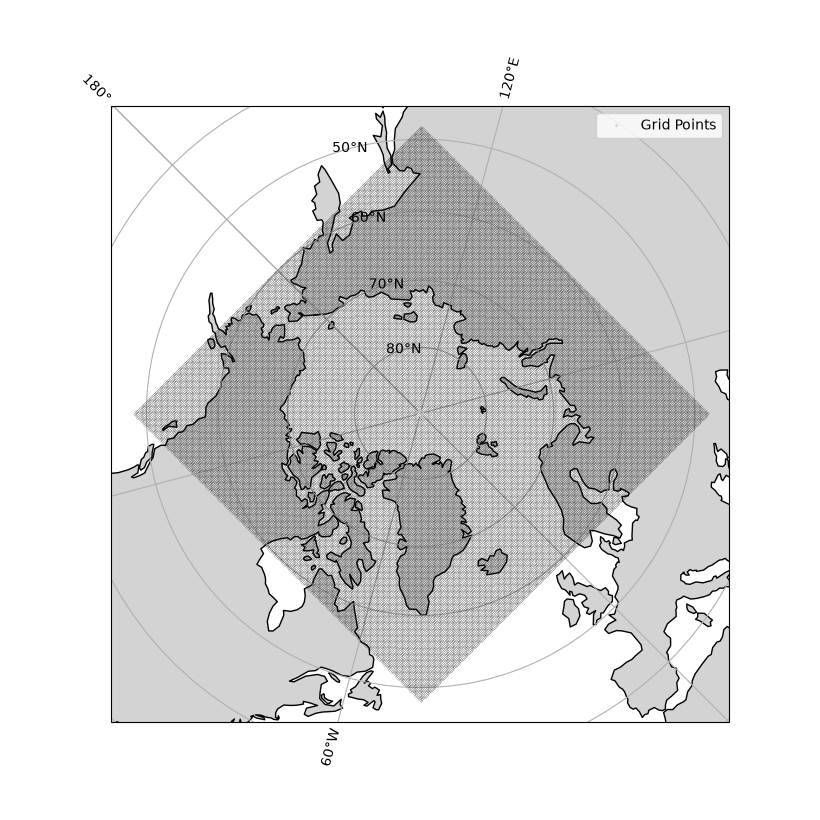

In [72]:
location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-45)
extent = [-165, 165, 45, 90]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)

ax = mapper.plot_locations(ax = ax, lat = new_data['lats'][::2], lon = new_data['lons'][::2], label = 'Grid Points', markersize=0.125)

plt.legend()
ax.set_title("CryoSat-2 DOT Grid Points")
plt.show()

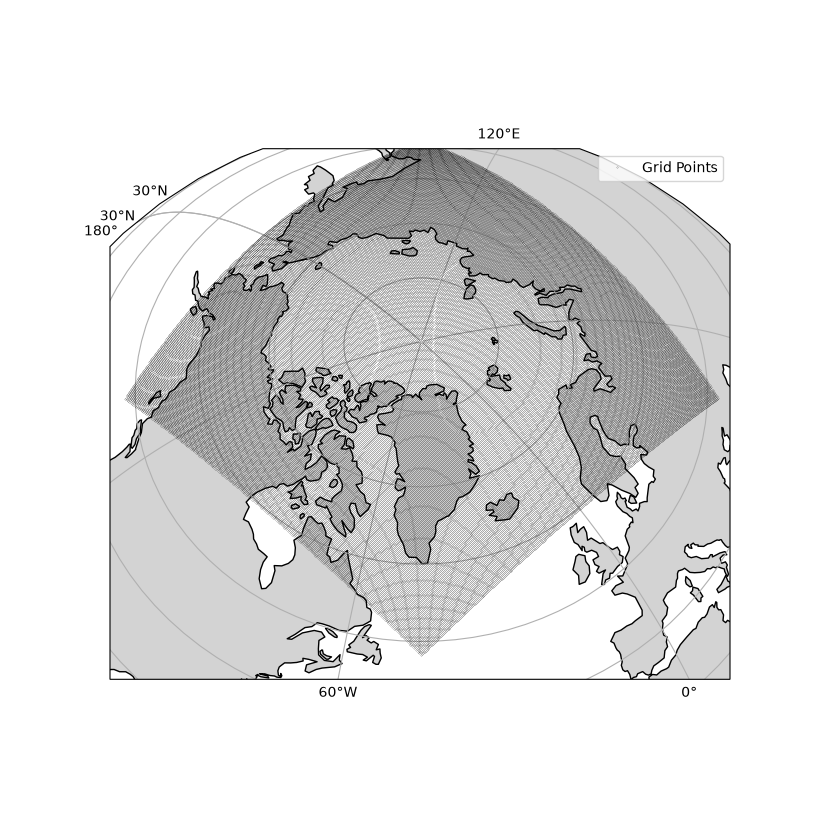

In [71]:
location_figure = plt.figure(figsize=(8,8))
projection=ccrs.Orthographic(central_longitude=-45, central_latitude=60)
extent = [-165, 165, 45, 90]

ax = mapper.setup_map(figure=location_figure,
                 projection=projection,
                 extent=extent)

ax = mapper.plot_locations(ax = ax, lat = new_data['lats'][::2], lon = new_data['lons'][::2], label = 'Grid Points', markersize=0.125)

plt.legend()
ax.set_title("CryoSat-2 DOT Grid Points")
plt.show()